# Sesión de clase 08 · Reportes cruzados: tópicos, sentimiento, clientes y ubicación

Los tópicos y el sentimiento se vuelven útiles para el negocio cuando se
**cruzan** con otras tablas: ¿de qué se quejan en cada país?, ¿qué categorías
de producto generan reclamos de entrega?, ¿qué clientes valiosos están
insatisfechos y con qué tema?

**Datos (`data/`):**
- `comentarios.csv` — 135 comentarios sobre la tienda (con país y ciudad).
- `resenas_entrega.csv` — 110 reseñas de entrega de un producto comprado.
- `productos.csv` — 90 productos con categoría y precio.
- `clientes.csv` — 120 clientes de 7 países (**datos personales**: DNI,
  nombre, correo).

**Etapas:** A. Unir y seudonimizar · B. Tópicos en 245 textos ·
C. Sentimiento · D. Por ubicación · E. Por categoría de producto ·
F. Por cliente · G. En el tiempo · Hallazgos.

**Regla de este notebook:** con 245 textos muchas combinaciones tienen 2 o 3
casos. Toda cifra se muestra con su **n**, y no se calculan indicadores para
grupos con menos de `N_MIN` textos.

In [1]:
import hashlib
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bertopic import BERTopic
from hdbscan import HDBSCAN
from pysentimiento import create_analyzer
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP

pd.set_option("display.max_colwidth", 100)
SALIDAS = Path("../salidas")
SALIDAS.mkdir(exist_ok=True)
N_MIN = 5

AZUL, ROJO, GRIS, TINTA = "#2a78d6", "#e34948", "#8a8985", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRIS, "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "figure.dpi": 110,
})

## Etapa A — Unir y seudonimizar

### A.1 Seudonimizar `clientes.csv`

Reemplazamos DNI, nombre y correo por un **código**: un *hash* SHA-256 del DNI
con una **sal** secreta. El mismo cliente siempre recibe el mismo código, pero
no se puede recuperar el DNI a partir de él (Ley N.° 29733 de Protección de
Datos Personales). `cliente_id` es una clave interna de la tienda: la
conservamos para unir tablas.

In [2]:
SAL = "mineria-web-s08"   # en producción: fuera del código (variable de entorno)

clientes = pd.read_csv("../data/clientes.csv")
clientes["codigo"] = ["C-" + hashlib.sha256(f"{SAL}{dni}".encode()).hexdigest()[:8]
                      for dni in clientes["dni"]]
clientes = clientes.drop(columns=["dni", "nombre", "apellidos", "email"])
clientes.head()

,id,ciudad,pais,codigo
0,1,Lima,Peru,C-10d2959b
1,2,Lima,Peru,C-acefa649
2,3,Lima,Peru,C-27baaf45
3,4,Arequipa,Peru,C-0d5215e6
4,5,Arequipa,Peru,C-7ae40488


### A.2 Un solo corpus de 245 textos

`resenas_entrega.csv` no tiene país ni ciudad, y `comentarios.csv` no tiene
producto. Con dos **JOIN** cada texto hereda:

- de `clientes.csv` (por `cliente_id`): código, país y ciudad;
- de `productos.csv` (por `producto_id`, solo reseñas): categoría y precio.

`how="left"` conserva todos los textos aunque no encuentren pareja: así
detectamos claves huérfanas.

In [3]:
c = pd.read_csv("../data/comentarios.csv")
r = pd.read_csv("../data/resenas_entrega.csv")
productos = pd.read_csv("../data/productos.csv")

textos = pd.concat([
    c[["cliente_id", "calificacion", "fecha", "texto"]].assign(fuente="comentario"),
    r[["cliente_id", "producto_id", "calificacion", "fecha", "texto"]].assign(fuente="reseña"),
], ignore_index=True)

textos = (textos
          .merge(clientes[["id", "codigo", "pais", "ciudad"]], left_on="cliente_id",
                 right_on="id", how="left").drop(columns="id")
          .merge(productos[["id", "categoria", "precio"]], left_on="producto_id",
                 right_on="id", how="left").drop(columns="id"))
textos["fecha"] = pd.to_datetime(textos["fecha"])

print("Textos:", len(textos), "  sin país:", textos["pais"].isna().sum(),
      "  reseñas sin categoría:", textos.loc[textos["fuente"] == "reseña", "categoria"].isna().sum())
textos.sample(5, random_state=1)

Textos: 245   sin país: 0   reseñas sin categoría: 0


,cliente_id,calificacion,fecha,texto,fuente,producto_id,codigo,pais,ciudad,categoria,precio
67,14,4,2025-04-26,"Buena variedad de opciones de envio, elegi la mas economica sin problema.",comentario,NaN,C-d1e65463,Peru,Iquitos,NaN,NaN
244,84,5,2024-01-07,"Mi Acer Aspire 5 llego en dos dias habiles, muy bien empacada y sin ningun golpe.",reseña,18.0,C-584205f3,Argentina,Rosario,Laptops y Computadoras,2299.0
207,85,3,2026-06-01,El robot aspiradora funciona bien pero el filtro se ensucia mas rapido de lo que esperaba.,reseña,73.0,C-b872a31e,Argentina,Mendoza,Electrodomesticos Inteligentes,1899.0
221,29,3,2024-03-14,"La camara instantanea llego a tiempo, el empaque estaba en buen estado aunque algo genérico para...",reseña,69.0,C-cabbdcbd,Peru,Lima,Fotografia y Video,349.0
90,58,2,2024-11-17,Las fotos de un producto no coincidian del todo con el color que llego. No es un problema grave ...,comentario,NaN,C-eb6f7feb,Colombia,Medellin,NaN,NaN


In [19]:
pd.crosstab(textos["pais"], textos["fuente"], margins=True, margins_name="Total")

fuente,comentario,reseña,Total
pais,,,
Argentina,15,18,33
Chile,18,9,27
Colombia,15,8,23
Ecuador,13,12,25
Mexico,9,10,19
Peru,57,46,103
Uruguay,8,7,15
Total,135,110,245


## Etapa B — Tópicos en los 245 textos

La misma configuración de los ejercicios, ahora con más textos:
`min_cluster_size=5`. Reasignamos el ruido (−1) para que todos los textos
entren en los cruces. Cada tópico se nombra **automáticamente** con sus tres
palabras principales; pueden reemplazarlas por un nombre escrito en
`NOMBRES`.

In [20]:
docs = textos["texto"].tolist()
st = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = st.encode(docs, show_progress_bar=True)


def normalizar(texto):
    t = unicodedata.normalize("NFKD", texto.lower())
    return "".join(ch for ch in t if not unicodedata.combining(ch))


STOPWORDS_ES = sorted(set("""
a al algo algun alguna algunas alguno algunos ante antes aqui asi aun aunque
bajo bien cada casi como con contra cual cuando de del desde donde dos durante
e el ella ellas ellos en entre era eran es esa esas ese eso esos esta estaba
estaban estan estar este esto estos fue fueron ha habia han hasta hay he la las
le les lo los mas me mi mis mucho muy nada ni no nos o otra otras otro otros
para pero poco por porque que se ser si sin sobre solo su sus tambien tan tanto
te tiene todo todos tu tuve un una uno unos y ya yo vez veces mismo misma
son podria poder bastante
""".split()))


def vectorizador():
    return CountVectorizer(preprocessor=normalizar, stop_words=STOPWORDS_ES)


topic_model = BERTopic(
    embedding_model=st,
    umap_model=UMAP(n_neighbors=10, n_components=5, min_dist=0.0,
                    metric="cosine", random_state=42),
    hdbscan_model=HDBSCAN(min_cluster_size=5, prediction_data=True),
    vectorizer_model=vectorizador(),
)
topicos, _ = topic_model.fit_transform(docs, embeddings)
topicos = topic_model.reduce_outliers(docs, topicos, strategy="c-tf-idf")
topic_model.update_topics(docs, topics=topicos, vectorizer_model=vectorizador())

NOMBRES = {}   # p. ej., {0: "Entregas tardías"}


def nombre(k):
    return NOMBRES.get(k, f"{k} · " + ", ".join(w for w, _ in topic_model.get_topic(k)[:3]))


textos["topico"] = [nombre(k) for k in topicos]
print(textos["topico"].nunique(), "tópicos")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

2026-10-06 17:51:24,441 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


8 tópicos


### B.1 ¿De qué fuente viene cada tópico?

Los comentarios hablan de la **tienda** (sitio, soporte, pagos) y las reseñas
de la **entrega y el producto**. Un tópico que mezcla ambas fuentes es un tema
transversal.

In [21]:
por_fuente = pd.crosstab(textos["topico"], textos["fuente"])
por_fuente["% reseñas"] = (100 * por_fuente["reseña"] / por_fuente.sum(axis=1)).round(0)
por_fuente.sort_values("% reseñas")

fuente,comentario,reseña,% reseñas
topico,,,
"0 · buena, tiendas, producto",67,1,1.0
"4 · proceso, pago, esperaba",10,1,9.0
"7 · sitio, general, leer",8,1,11.0
"1 · correo, soporte, llego",38,20,34.0
"2 · caja, llego, pantalla",7,41,85.0
"5 · galaxy, s24, xps",2,11,85.0
"3 · ningun, llego, acer",3,24,89.0
"6 · xiaomi, tv, hervidor",0,11,100.0


## Etapa C — Sentimiento

`pysentimiento` (RoBERTuito, español) clasifica cada texto en POS, NEU o NEG.
Con eso definimos, para cualquier grupo:

- **neto** = %POS − %NEG (de −1 a +1);
- **polarización** = 2 × mín(%POS, %NEG) (de 0 a 1).

In [22]:
analizador = create_analyzer(task="sentiment", lang="es")
textos["sent"] = [p.output for p in analizador.predict(docs)]


def indicadores(grupo):
    pos, neg = (grupo["sent"] == "POS").mean(), (grupo["sent"] == "NEG").mean()
    return pd.Series({"n": len(grupo), "%NEG": neg, "neto": pos - neg,
                      "polarizacion": 2 * min(pos, neg),
                      "calif. promedio": grupo["calificacion"].mean()})


por_topico = textos.groupby("topico").apply(indicadores, include_groups=False)
por_topico["n"] = por_topico["n"].astype(int)
por_topico.sort_values("neto").round(2)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/245 [00:00<?, ? examples/s]

,n,%NEG,neto,polarizacion,calif. promedio
topico,,,,,
"1 · correo, soporte, llego",58,0.53,-0.43,0.21,2.47
"2 · caja, llego, pantalla",48,0.29,-0.08,0.42,3.02
"4 · proceso, pago, esperaba",11,0.27,0.00,0.55,3.36
"7 · sitio, general, leer",9,0.33,0.11,0.67,3.22
"6 · xiaomi, tv, hervidor",11,0.09,0.27,0.18,4.09
"0 · buena, tiendas, producto",68,0.16,0.38,0.32,3.75
"3 · ningun, llego, acer",27,0.00,0.67,0.00,4.33
"5 · galaxy, s24, xps",13,0.00,0.85,0.00,4.85


## Etapa D — Por ubicación

### D.1 Mapa de calor país × tópico

Cada celda es el sentimiento neto del tópico en ese país. Las celdas con menos
de `N_MIN` textos quedan en blanco: un solo texto más cambiaría la cifra en
20 puntos o más.

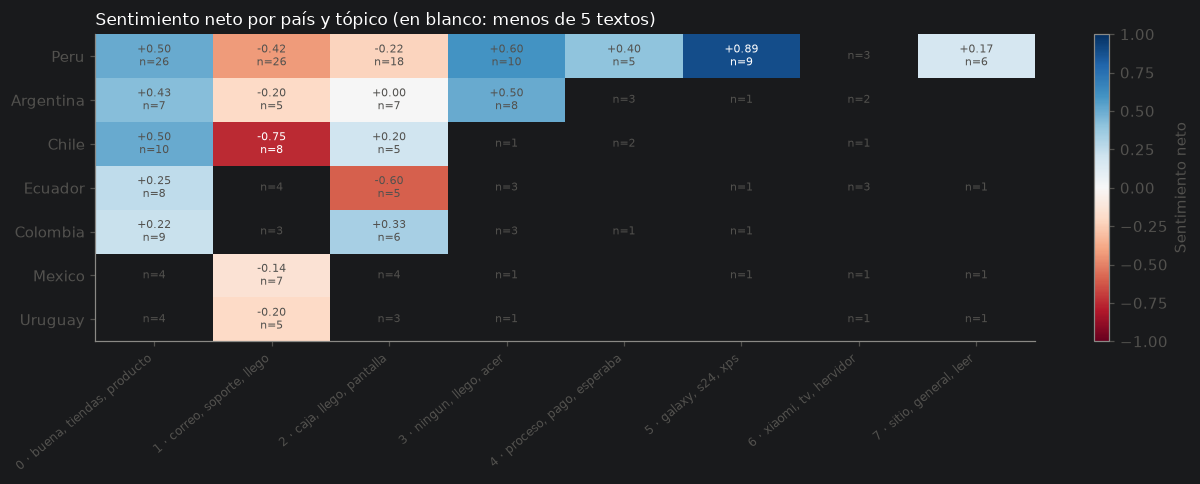

In [23]:
celdas = textos.groupby(["pais", "topico"]).apply(indicadores, include_groups=False)
neto = celdas["neto"].unstack()
n = celdas["n"].unstack().fillna(0).astype(int)
neto_visible = neto.where(n >= N_MIN)

orden_paises = textos["pais"].value_counts().index
neto_visible, n = neto_visible.loc[orden_paises], n.loc[orden_paises]

fig, ax = plt.subplots(figsize=(min(1.1 * neto.shape[1] + 3, 16), 4.5))
im = ax.imshow(neto_visible, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")
for i in range(n.shape[0]):
    for j in range(n.shape[1]):
        v, k = neto_visible.iat[i, j], n.iat[i, j]
        if k:
            ax.text(j, i, f"{v:+.2f}\nn={k}" if pd.notna(v) else f"n={k}",
                    ha="center", va="center", fontsize=7,
                    color="white" if pd.notna(v) and abs(v) > 0.6 else TINTA)
ax.set_xticks(range(n.shape[1]), n.columns, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(n.shape[0]), n.index)
ax.grid(False)
fig.colorbar(im, ax=ax, label="Sentimiento neto")
ax.set_title(f"Sentimiento neto por país y tópico (en blanco: menos de {N_MIN} textos)",
             loc="left", fontsize=11)
plt.tight_layout()
plt.savefig(SALIDAS / "neto_pais_topico.png")
plt.show()

### D.2 Resumen por país: ¿cuál es el tema más negativo de cada uno?

In [24]:
def peor_topico(grupo):
    t = grupo.groupby("topico").apply(indicadores, include_groups=False)
    t = t[t["n"] >= 3]
    if t.empty:
        return pd.Series({"tópico más negativo": "—", "neto del tópico": np.nan, "n del tópico": 0})
    k = t["neto"].idxmin()
    return pd.Series({"tópico más negativo": k, "neto del tópico": t.loc[k, "neto"],
                      "n del tópico": int(t.loc[k, "n"])})


resumen_pais = textos.groupby("pais").apply(indicadores, include_groups=False)
resumen_pais = resumen_pais.join(textos.groupby("pais").apply(peor_topico, include_groups=False))
resumen_pais["n"] = resumen_pais["n"].astype(int)
resumen_pais = resumen_pais.sort_values("neto")
resumen_pais.round(2).to_csv(SALIDAS / "resumen_por_pais.csv")
resumen_pais.round(2)

,n,%NEG,neto,polarizacion,calif. promedio,tópico más negativo,neto del tópico,n del tópico
pais,,,,,,,,
Uruguay,15,0.40,-0.13,0.53,2.93,"2 · caja, llego, pantalla",-0.33,3
Chile,27,0.30,0.04,0.59,3.15,"1 · correo, soporte, llego",-0.75,8
Ecuador,25,0.32,0.08,0.64,3.16,"1 · correo, soporte, llego",-0.75,4
Mexico,19,0.26,0.11,0.53,3.74,"1 · correo, soporte, llego",-0.14,7
Peru,103,0.26,0.16,0.52,3.51,"1 · correo, soporte, llego",-0.42,26
Argentina,33,0.15,0.18,0.30,3.52,"4 · proceso, pago, esperaba",-0.33,3
Colombia,23,0.17,0.22,0.35,3.35,"1 · correo, soporte, llego",-0.67,3


### D.3 Ciudades con suficientes textos

Perú concentra la mitad de los clientes; bajamos a nivel de ciudad solo donde
hay al menos `2 × N_MIN` textos.

In [25]:
por_ciudad = textos.groupby(["pais", "ciudad"]).apply(indicadores, include_groups=False)
por_ciudad = por_ciudad[por_ciudad["n"] >= 2 * N_MIN]
por_ciudad["n"] = por_ciudad["n"].astype(int)
por_ciudad.sort_values("neto").round(2)

n  %NEG  neto  polarizacion  calif. promedio
pais      ciudad                                                         
Chile     Santiago          13  0.46 -0.31          0.31             2.85
Argentina Mendoza           10  0.30  0.00          0.60             3.50
Mexico    Ciudad de Mexico  10  0.30  0.00          0.60             3.30
Peru      Trujillo          11  0.27  0.09          0.55             3.55
          Chiclayo          10  0.20  0.10          0.40             3.50
          Lima              27  0.19  0.30          0.37             3.81
          Cusco             12  0.25  0.33          0.50             3.42

## Etapa E — Por categoría de producto

Solo las **reseñas** tienen producto. ¿Qué categorías concentran las quejas y
de qué tema son?

In [26]:
resenas = textos[textos["fuente"] == "reseña"]
por_categoria = resenas.groupby("categoria").apply(indicadores, include_groups=False)
por_categoria["n"] = por_categoria["n"].astype(int)
por_categoria["tópico más frecuente"] = resenas.groupby("categoria")["topico"].agg(
    lambda s: s.value_counts().index[0])
por_categoria = por_categoria.sort_values("neto")
por_categoria.round(2).to_csv(SALIDAS / "resumen_por_categoria.csv")
por_categoria.round(2)

,n,%NEG,neto,polarizacion,calif. promedio,tópico más frecuente
categoria,,,,,,
Electrodomesticos Inteligentes,12,0.17,-0.17,0.00,3.33,"6 · xiaomi, tv, hervidor"
Smartphones,13,0.31,0.08,0.62,3.00,"2 · caja, llego, pantalla"
Wearables y Fitness,12,0.17,0.08,0.33,3.50,"2 · caja, llego, pantalla"
Audio,13,0.38,0.15,0.77,4.00,"2 · caja, llego, pantalla"
Accesorios y Componentes,12,0.08,0.17,0.17,3.50,"2 · caja, llego, pantalla"
Televisores y Video,13,0.23,0.31,0.46,3.77,"6 · xiaomi, tv, hervidor"
Gaming y Consolas,12,0.08,0.33,0.17,4.00,"3 · ningun, llego, acer"
Fotografia y Video,11,0.09,0.36,0.18,3.45,"3 · ningun, llego, acer"
Laptops y Computadoras,12,0.17,0.42,0.33,3.67,"3 · ningun, llego, acer"


In [27]:
quejas = resenas[resenas["sent"] == "NEG"]
pd.crosstab(quejas["categoria"], quejas["topico"], margins=True, margins_name="Total")

topico,"1 · correo, soporte, llego","2 · caja, llego, pantalla","4 · proceso, pago, esperaba","6 · xiaomi, tv, hervidor",Total
categoria,,,,,
Accesorios y Componentes,0,1,0,0,1
Audio,2,3,0,0,5
Electrodomesticos Inteligentes,1,0,1,0,2
Fotografia y Video,1,0,0,0,1
Gaming y Consolas,1,0,0,0,1
Laptops y Computadoras,1,1,0,0,2
Smartphones,0,4,0,0,4
Televisores y Video,0,2,0,1,3
Wearables y Fitness,0,2,0,0,2


## Etapa F — Por cliente

### F.1 Perfil de cada cliente

Por código seudonimizado: cuántos textos escribió, de cuántos tópicos
distintos, su sentimiento neto, su tópico principal, en qué tópicos se quejó
y el **valor comprado**. El valor solo se conoce por las reseñas (cada una
corresponde a un producto comprado): es una **aproximación** que subestima a
los clientes que compran sin reseñar.

In [28]:
def perfil(grupo):
    neg = grupo[grupo["sent"] == "NEG"]
    return pd.Series({
        "pais": grupo["pais"].iloc[0],
        "textos": len(grupo),
        "topicos distintos": grupo["topico"].nunique(),
        "neto": (grupo["sent"] == "POS").mean() - (grupo["sent"] == "NEG").mean(),
        "topico principal": grupo["topico"].value_counts().index[0],
        "quejas": len(neg),
        "topicos con queja": " | ".join(sorted(neg["topico"].unique())),
        "valor comprado": grupo["precio"].sum(),
    })


perfiles = textos.groupby("codigo").apply(perfil, include_groups=False)
perfiles.to_csv(SALIDAS / "perfil_clientes_topicos.csv")
print(f"{len(perfiles)} clientes con al menos un texto de {len(clientes)}")
perfiles.sort_values("textos", ascending=False).head(8).round(2)

105 clientes con al menos un texto de 120


,pais,textos,topicos distintos,neto,topico principal,quejas,topicos con queja,valor comprado
codigo,,,,,,,,
C-10d2959b,Peru,11,4,0.73,"5 · galaxy, s24, xps",0,,48790.0
C-82db662b,Peru,6,5,0.17,"1 · correo, soporte, llego",2,"1 · correo, soporte, llego | 7 · sitio, general, leer",5256.0
C-b872a31e,Argentina,6,5,0.17,"4 · proceso, pago, esperaba",1,"4 · proceso, pago, esperaba",15495.0
C-8e080668,Peru,6,4,0.50,"0 · buena, tiendas, producto",1,"1 · correo, soporte, llego",19196.0
C-0796c15c,Ecuador,5,4,0.60,"0 · buena, tiendas, producto",0,,2897.0
C-0aa896eb,Colombia,5,3,0.00,"2 · caja, llego, pantalla",1,"1 · correo, soporte, llego",3657.0
C-fc81f112,Peru,5,4,0.60,"0 · buena, tiendas, producto",0,,10997.0
C-2bafd967,Mexico,4,3,0.00,"1 · correo, soporte, llego",1,"1 · correo, soporte, llego",1348.0


### F.2 Clientes con quejas en varios tópicos

Un cliente que se queja de **dos o más temas distintos** tiene una mala
experiencia general, no un incidente aislado.

In [29]:
multi_queja = perfiles[perfiles["topicos con queja"].str.count(r"\|") >= 1]
print(f"{len(multi_queja)} clientes con quejas en 2 o más tópicos")
multi_queja.sort_values("quejas", ascending=False)[
    ["pais", "textos", "quejas", "topicos con queja", "neto"]].round(2)

12 clientes con quejas en 2 o más tópicos


,pais,textos,quejas,topicos con queja,neto
codigo,,,,,
C-12a37385,Ecuador,2,2,"0 · buena, tiendas, producto | 2 · caja, llego, pantalla",-1.00
C-26aebf92,Ecuador,2,2,"1 · correo, soporte, llego | 2 · caja, llego, pantalla",-1.00
C-5fc403c9,Mexico,2,2,"0 · buena, tiendas, producto | 1 · correo, soporte, llego",-1.00
C-82db662b,Peru,6,2,"1 · correo, soporte, llego | 7 · sitio, general, leer",0.17
C-89867460,Argentina,2,2,"0 · buena, tiendas, producto | 1 · correo, soporte, llego",-1.00
C-9ed9a09e,Chile,2,2,"1 · correo, soporte, llego | 2 · caja, llego, pantalla",-1.00
C-a0b81c35,Peru,3,2,"1 · correo, soporte, llego | 2 · caja, llego, pantalla",-0.67
C-cabbdcbd,Peru,3,2,"1 · correo, soporte, llego | 4 · proceso, pago, esperaba",-0.33
C-d273ca98,Uruguay,2,2,"0 · buena, tiendas, producto | 7 · sitio, general, leer",-1.00


### F.3 Clientes valiosos insatisfechos, por tópico

Valiosos = valor comprado en el **25 % superior** (entre quienes tienen
reseñas); insatisfechos = neto < 0. ¿Por qué temas los estamos perdiendo?

In [30]:
con_compras = perfiles[perfiles["valor comprado"] > 0]
corte_valor = con_compras["valor comprado"].quantile(0.75)
en_riesgo = con_compras[(con_compras["valor comprado"] >= corte_valor) & (con_compras["neto"] < 0)]

print(f"Corte de valor (percentil 75): {corte_valor:,.0f}")
print(f"{len(en_riesgo)} clientes valiosos insatisfechos; "
      f"valor comprado en juego: {en_riesgo['valor comprado'].sum():,.0f}")
en_riesgo.sort_values("valor comprado", ascending=False)[
    ["pais", "valor comprado", "quejas", "topicos con queja"]].round(2)

Corte de valor (percentil 75): 3,548
4 clientes valiosos insatisfechos; valor comprado en juego: 21,394


,pais,valor comprado,quejas,topicos con queja
codigo,,,,
C-7463e8ba,Colombia,6999.0,1,"1 · correo, soporte, llego"
C-a0b81c35,Peru,5999.0,2,"1 · correo, soporte, llego | 2 · caja, llego, pantalla"
C-9ed9a09e,Chile,4798.0,2,"1 · correo, soporte, llego | 2 · caja, llego, pantalla"
C-92ba1db0,Mexico,3598.0,1,"2 · caja, llego, pantalla"


In [31]:
temas_riesgo = (en_riesgo["topicos con queja"].str.split(r" \| ").explode()
                .replace("", np.nan).dropna().value_counts().rename("clientes valiosos con queja"))
temas_riesgo.to_frame()

,clientes valiosos con queja
topicos con queja,
"1 · correo, soporte, llego",3
"2 · caja, llego, pantalla",3


### F.4 Clientes silenciosos

Los clientes sin ningún texto no son «neutros»: su opinión es
**desconocida**.

In [32]:
silenciosos = clientes[~clientes["codigo"].isin(perfiles.index)]
print(f"{len(silenciosos)} de {len(clientes)} clientes no escribieron ningún texto")
silenciosos.groupby("pais").size().rename("silenciosos").to_frame().T

15 de 120 clientes no escribieron ningún texto


pais,Argentina,Chile,Colombia,Ecuador,Mexico,Peru,Uruguay
silenciosos,1,2,3,4,1,2,2


## Etapa G — En el tiempo

Sentimiento neto por trimestre para los cuatro tópicos con más textos. Los
puntos con menos de `N_MIN` textos no se dibujan.

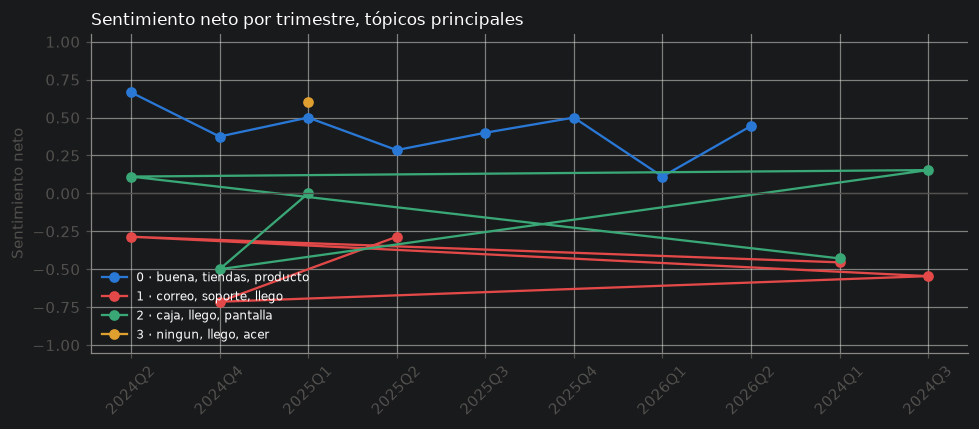

In [33]:
textos["trimestre"] = textos["fecha"].dt.to_period("Q")
principales = textos["topico"].value_counts().index[:4]

fig, ax = plt.subplots(figsize=(9, 4))
paleta = [AZUL, ROJO, "#3aa776", "#e0a030"]
for color, t in zip(paleta, principales):
    serie = (textos[textos["topico"] == t].groupby("trimestre")
             .apply(indicadores, include_groups=False))
    serie = serie[serie["n"] >= N_MIN]
    ax.plot(serie.index.astype(str), serie["neto"], "o-", color=color, label=t)
ax.axhline(0, color=TINTA, linewidth=0.8)
ax.set_ylim(-1.05, 1.05)
ax.set_ylabel("Sentimiento neto")
ax.set_title("Sentimiento neto por trimestre, tópicos principales", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="lower left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(SALIDAS / "neto_trimestral_topicos.png")
plt.show()

## Hallazgos

Respondan con las tablas y gráficos de este notebook:

1. ¿Qué país tiene el sentimiento más bajo y **de qué tema** se queja? ¿Hay
   suficientes textos para afirmarlo?
2. ¿Qué categoría de producto genera más quejas de entrega? ¿Qué acción
   recomendarían?
3. ¿Cuántos clientes valiosos están insatisfechos y cuál es el tema que más
   se repite entre ellos? ¿Por qué el «valor comprado» subestima a algunos
   clientes?
4. ¿Qué tópicos son **transversales** (aparecen en comentarios y en
   reseñas)?
5. Limitaciones: tamaño de muestra, clientes silenciosos, errores del modelo
   de sentimiento y tópicos que cambian con la semilla.

**Respuestas del grupo**

1.
2.
3.
4.
5.